In [1]:
from collections import defaultdict, deque
import os
import glob

def read_directed_graph(file_path):
    graph = defaultdict(list)
    with open(file_path, 'r') as f:
        for line in f:
            u, v = map(int, line.strip().split())
            graph[u].append(v)
            if v not in graph:
                graph[v] = []
    return graph

def build_undirected(graph):
    undirected = defaultdict(set)
    for u in graph:
        for v in graph[u]:
            undirected[u].add(v)
            undirected[v].add(u)
        if u not in undirected:
            undirected[u] = set()
    return undirected

def weakly_connected_components(graph):
    undirected = build_undirected(graph)
    visited = set()
    components = []
    for node in undirected:
        if node not in visited:
            queue = deque([node])
            component = []
            while queue:
                v = queue.popleft()
                if v not in visited:
                    visited.add(v)
                    component.append(v)
                    queue.extend(undirected[v] - visited)
            components.append(component)
    return components

def reverse_graph(graph):
    reversed_g = defaultdict(list)
    for u in graph:
        for v in graph[u]:
            reversed_g[v].append(u)
        if u not in reversed_g:
            reversed_g[u] = []
    return reversed_g

def dfs_fill(graph, node, visited, order):
    stack = [node]
    temp_stack = []
    while stack:
        v = stack.pop()
        if v not in visited:
            visited.add(v)
            temp_stack.append(v)
            stack.extend([nei for nei in graph[v] if nei not in visited])
    while temp_stack:
        order.append(temp_stack.pop())

def dfs_collect(graph, node, visited, component):
    stack = [node]
    while stack:
        v = stack.pop()
        if v not in visited:
            visited.add(v)
            component.append(v)
            stack.extend([nei for nei in graph[v] if nei not in visited])

def kosaraju_scc(graph):
    visited = set()
    order = []
    for node in graph:
        if node not in visited:
            dfs_fill(graph, node, visited, order)
    reversed_g = reverse_graph(graph)
    visited.clear()
    components = []
    while order:
        node = order.pop()
        if node not in visited:
            component = []
            dfs_collect(reversed_g, node, visited, component)
            components.append(component)
    return components

txt_files = sorted(glob.glob(os.path.join("*.txt")))
for i, file in enumerate(txt_files, 1):
    print(f"\n[{i}/{len(txt_files)}] Файл: {os.path.basename(file)}")
    graph = read_directed_graph(os.path.basename(file))
    num_vertices = len(graph)
    num_edges = sum(len(neighbors) for neighbors in graph.values())
    max_edges = num_vertices * (num_vertices - 1) // 2
    density = num_edges / max_edges
    weak_components = weakly_connected_components(graph)
    num_weak = len(weak_components)
    largest_weak = max(len(comp) for comp in weak_components)
    weak_fraction = largest_weak / num_vertices
    strong_components = kosaraju_scc(graph)
    num_strong = len(strong_components)
    largest_strong = max(len(comp) for comp in strong_components)
    strong_fraction = largest_strong / num_vertices
    print(f"Число вершин: {num_vertices}")
    print(f"Число рёбер: {num_edges}")
    print(f"Плотность: {density}")
    print(f"Число компонент слабой связности: {num_weak}")
    print(f"Доля вершин в крупнейшей компоненте слабой компоненте: {weak_fraction}")
    print(f"Число компонент сильной связности: {num_strong}")
    print(f"Доля вершин в крупнейшей компоненте сильной компоненте: {strong_fraction}")


[1/23] Файл: CA-AstroPh.txt
Число вершин: 18772
Число рёбер: 396160
Плотность: 0.002248550591304214
Число компонент слабой связности: 290
Доля вершин в крупнейшей компоненте слабой компоненте: 0.9537076496910292
Число компонент сильной связности: 290
Доля вершин в крупнейшей компоненте сильной компоненте: 0.9537076496910292

[2/23] Файл: CA-GrQc.txt
Число вершин: 5242
Число рёбер: 28980
Плотность: 0.0021096829862802904
Число компонент слабой связности: 355
Доля вершин в крупнейшей компоненте слабой компоненте: 0.7932086989698588
Число компонент сильной связности: 355
Доля вершин в крупнейшей компоненте сильной компоненте: 0.7932086989698588

[3/23] Файл: Email-EuAll.txt
Число вершин: 265214
Число рёбер: 420045
Плотность: 1.1943581056223159e-05
Число компонент слабой связности: 15836
Доля вершин в крупнейшей компоненте слабой компоненте: 0.847738053043957
Число компонент сильной связности: 230840
Доля вершин в крупнейшей компоненте сильной компоненте: 0.1289637801925992

[4/23] Файл: W

In [2]:
import random
import numpy as np
from collections import defaultdict, deque
import os
import glob

def read_graph(path):
    graph = defaultdict(set)
    with open(path, 'r') as f:
        for line in f:
            u, v = map(int, line.strip().split())
            if u == v:
                continue
            graph[u].add(v)
            graph[v].add(u)
    return graph

def bfs_distances(graph, start):
    distances = {start: 0}
    queue = deque([start])
    while queue:
        node = queue.popleft()
        for neighbor in graph[node]:
            if neighbor not in distances:
                distances[neighbor] = distances[node] + 1
                queue.append(neighbor)
    return distances

def get_largest_connected_component(graph):
    visited = set()
    largest_component = []
    nodes = list(graph.keys())
    for node in nodes:
        if node in visited:
            continue
        component = []
        queue = deque([node])
        visited.add(node)
        while queue:
            current = queue.popleft()
            component.append(current)
            for neighbor in graph[current]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
        if len(component) > len(largest_component):
            largest_component = component
    component_set = set(largest_component)
    subgraph = {v: graph[v] & component_set for v in component_set}
    return subgraph

def double_sweep_diameter(graph):
    r = random.choice(list(graph.keys()))
    dist1 = bfs_distances(graph, r)
    a = max(dist1, key=dist1.get)
    dist2 = bfs_distances(graph, a)
    b = max(dist2, key=dist2.get)
    return dist2[b]

def sample_distances(graph, sources=10, targets_per_source=50):
    nodes = list(graph.keys())
    distances = []
    for _ in range(sources):
        src = random.choice(nodes)
        dist_map = bfs_distances(graph, src)
        others = [v for v in dist_map if v != src]
        if not others:
            continue
        sampled = random.sample(others, min(targets_per_source, len(others)))
        distances.extend(dist_map[v] for v in sampled)
    return np.percentile(distances, 90)

def snowball_sample(graph, target_size=500, max_expand=200):
    seed = random.sample(list(graph.keys()), 2)
    visited = set(seed)
    queue = deque(seed)
    while queue and len(visited) < target_size:
        node = queue.popleft()
        neighbors = graph[node] - visited
        if len(neighbors) > max_expand:
            neighbors = random.sample(list(neighbors), max_expand)
        for neigh in neighbors:
            visited.add(neigh)
            queue.append(neigh)
            if len(visited) >= target_size:
                break
    return {v: graph[v] & visited for v in visited}

txt_files = sorted(glob.glob(os.path.join("*.txt")))
for i, file in enumerate(txt_files, 1):
    print(f"\n[{i}/{len(txt_files)}] Файл: {os.path.basename(file)}")
    graph = read_graph(os.path.basename(file))
    largest_cc = get_largest_connected_component(graph)
    diameter = double_sweep_diameter(largest_cc)
    print("Оценка диаметра (double sweep):", diameter)
    perc90 = sample_distances(largest_cc)
    print("90-й перцентиль расстояний:", round(perc90, 2))
    snowball = snowball_sample(largest_cc, 500)
    if len(snowball) >= 2:
        sb_diameter = double_sweep_diameter(snowball)
        sb_perc90 = sample_distances(snowball)
        print("Диаметр снежного кома (double sweep):", sb_diameter)
        print("90-й перцентиль снежного кома:", round(sb_perc90, 2))
    else:
        print("Снежный ком из 500 вершин не построен :(")



[1/23] Файл: CA-AstroPh.txt
Оценка диаметра (double sweep): 13
90-й перцентиль расстояний: 6.0
Диаметр снежного кома (double sweep): 4
90-й перцентиль снежного кома: 3.0

[2/23] Файл: CA-GrQc.txt
Оценка диаметра (double sweep): 17
90-й перцентиль расстояний: 7.1
Диаметр снежного кома (double sweep): 8
90-й перцентиль снежного кома: 6.0

[3/23] Файл: Email-EuAll.txt
Оценка диаметра (double sweep): 14
90-й перцентиль расстояний: 5.0
Диаметр снежного кома (double sweep): 5
90-й перцентиль снежного кома: 4.0

[4/23] Файл: Wiki-Vote.txt
Оценка диаметра (double sweep): 6
90-й перцентиль расстояний: 4.0
Диаметр снежного кома (double sweep): 3
90-й перцентиль снежного кома: 3.0

[5/23] Файл: ca-coauthors-dblp.txt
Оценка диаметра (double sweep): 23
90-й перцентиль расстояний: 7.0
Диаметр снежного кома (double sweep): 3
90-й перцентиль снежного кома: 3.0

[6/23] Файл: com-youtube.ungraph.txt
Оценка диаметра (double sweep): 24
90-й перцентиль расстояний: 6.0
Диаметр снежного кома (double sweep):

In [3]:
from collections import defaultdict
import os
import glob

def read_graph(path):
    graph = defaultdict(set)
    with open(path, 'r') as f:
        for line in f:
            u, v = map(int, line.strip().split())
            if u == v:
                continue
            graph[u].add(v)
            graph[v].add(u)
    return graph

def count_triangles(graph):
    triangle_count = 0
    for u in graph:
        for v in graph[u]:
            if v > u:
                common = graph[u] & graph[v]
                triangle_count = triangle_count + len([w for w in common if w > v])
    return triangle_count

def global_clustering_coefficient(graph, triangle_count):
    triples = 0
    for v in graph:
        deg = len(graph[v])
        if deg >= 2:
            triples = triples + deg * (deg - 1) // 2
    return (3 * triangle_count / triples)

def average_clustering_coefficient(graph):
    total = 0
    count = 0
    for node in graph:
        neighbors = graph[node]
        k = len(neighbors)
        if k < 2:
            continue
        links = 0
        neighbors_list = list(neighbors)
        for i in range(k):
            for j in range(i + 1, k):
                u, v = neighbors_list[i], neighbors_list[j]
                if u in graph[v]:
                    links = links + 1
        total = total + (2 * links) / (k * (k - 1))
        count = count + 1
    return total / count

txt_files = sorted(glob.glob(os.path.join("*.txt")))
for i, file in enumerate(txt_files, 1):
    print(f"\n[{i}/{len(txt_files)}] Файл: {os.path.basename(file)}")
    graph = read_graph(os.path.basename(file))
    tri_count = count_triangles(graph)
    print(f"Число треугольников: {tri_count}")
    gcc = global_clustering_coefficient(graph, tri_count)
    print(f"Глобальный кластерный коэффициент: {gcc}")
    acc = average_clustering_coefficient(graph)
    print(f"Средний кластерный коэффициент: {acc}")


[1/23] Файл: CA-AstroPh.txt
Число треугольников: 1351441
Глобальный кластерный коэффициент: 0.3180015812533629
Средний кластерный коэффициент: 0.6768538122967666

[2/23] Файл: CA-GrQc.txt
Число треугольников: 48260
Глобальный кластерный коэффициент: 0.6298424741263426
Средний кластерный коэффициент: 0.6865358361857805

[3/23] Файл: Email-EuAll.txt
Число треугольников: 267313
Глобальный кластерный коэффициент: 0.004106431079830243
Средний кластерный коэффициент: 0.45560601382894084

[4/23] Файл: Wiki-Vote.txt
Число треугольников: 608389
Глобальный кластерный коэффициент: 0.12547914899233995
Средний кластерный коэффициент: 0.20885170281860763

[5/23] Файл: ca-coauthors-dblp.txt
Число треугольников: 444095058
Глобальный кластерный коэффициент: 0.6561501456556504
Средний кластерный коэффициент: 0.8152474550396652

[6/23] Файл: com-youtube.ungraph.txt
Число треугольников: 3056386
Глобальный кластерный коэффициент: 0.006218559818028638
Средний кластерный коэффициент: 0.17225795952140308

[7

In [4]:
from collections import defaultdict, deque
import os
import glob

def read_graph(path):
    graph = defaultdict(set)
    with open(path, 'r') as f:
        for line in f:
            u, v = map(int, line.strip().split())
            if u == v:
                continue
            graph[u].add(v)
            graph[v].add(u)
    return graph

def get_largest_connected_component(graph):
    visited = set()
    largest_component = []
    nodes = list(graph.keys())
    for node in nodes:
        if node in visited:
            continue
        component = []
        queue = deque([node])
        visited.add(node)
        while queue:
            current = queue.popleft()
            component.append(current)
            for neighbor in graph[current]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
        if len(component) > len(largest_component):
            largest_component = component
    component_set = set(largest_component)
    subgraph = {v: graph[v] & component_set for v in component_set}
    return subgraph

def average_clustering_coefficient(graph):
    total = 0
    count = 0
    for node in graph:
        neighbors = graph[node]
        k = len(neighbors)
        if k < 2:
            continue
        links = 0
        neighbors_list = list(neighbors)
        for i in range(k):
            for j in range(i + 1, k):
                u, v = neighbors_list[i], neighbors_list[j]
                if u in graph[v]:
                    links = links + 1
        total = total + (2 * links) / (k * (k - 1))
        count = count + 1
    return total / count

txt_files = sorted(glob.glob(os.path.join("*.txt")))
for i, file in enumerate(txt_files, 1):
    print(f"\n[{i}/{len(txt_files)}] Файл: {os.path.basename(file)}")
    graph = read_graph(os.path.basename(file))
    lcc = get_largest_connected_component(graph)
    avg_c = average_clustering_coefficient(lcc)
    print(f"Средний кластерный коэффициент в наибольшей компоненте связанности: {avg_c}")


[1/23] Файл: CA-AstroPh.txt
Средний кластерный коэффициент в наибольшей компоненте связанности: 0.6685609532306014

[2/23] Файл: CA-GrQc.txt
Средний кластерный коэффициент в наибольшей компоненте связанности: 0.6648003510864177

[3/23] Файл: Email-EuAll.txt
Средний кластерный коэффициент в наибольшей компоненте связанности: 0.48696820796020057

[4/23] Файл: Wiki-Vote.txt
Средний кластерный коэффициент в наибольшей компоненте связанности: 0.20898231676658685

[5/23] Файл: ca-coauthors-dblp.txt
Средний кластерный коэффициент в наибольшей компоненте связанности: 0.8152474550396571

[6/23] Файл: com-youtube.ungraph.txt
Средний кластерный коэффициент в наибольшей компоненте связанности: 0.1722579595214077

[7/23] Файл: digraph_1.txt
Средний кластерный коэффициент в наибольшей компоненте связанности: 0.010362438833955876

[8/23] Файл: digraph_2.txt
Средний кластерный коэффициент в наибольшей компоненте связанности: 0.009086434046568705

[9/23] Файл: digraph_3.txt
Средний кластерный коэффици


[1/23] Файл: CA-AstroPh.txt
Мин. степень: 1
Макс. степень: 504
Средняя степень: 21.101699429971767


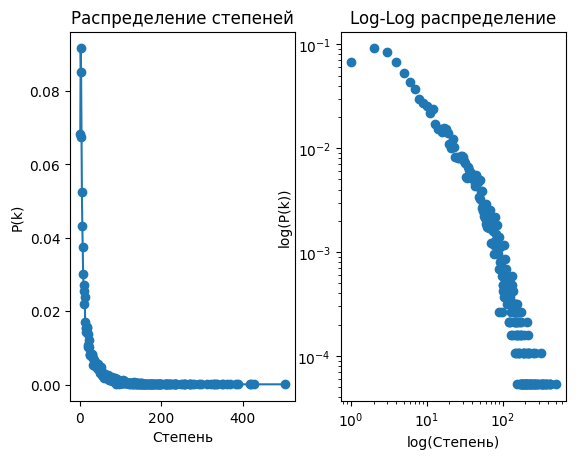


[2/23] Файл: CA-GrQc.txt
Мин. степень: 1
Макс. степень: 81
Средняя степень: 5.527189467658844


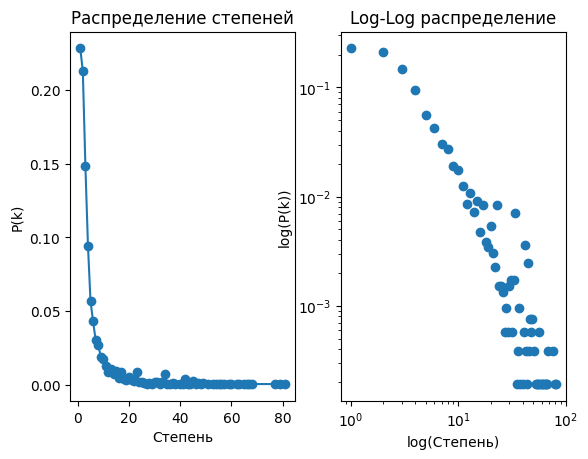


[3/23] Файл: Email-EuAll.txt
Мин. степень: 1
Макс. степень: 7636
Средняя степень: 2.7507065797765358


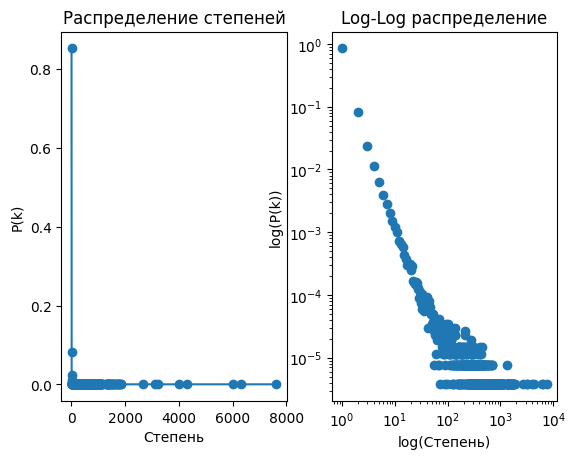


[4/23] Файл: Wiki-Vote.txt
Мин. степень: 1
Макс. степень: 1065
Средняя степень: 28.32382290934645


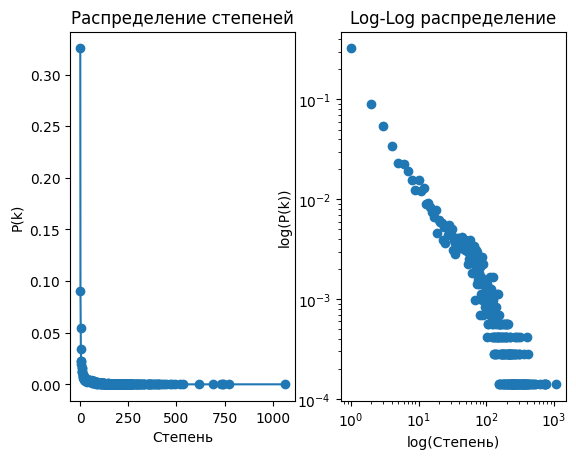


[5/23] Файл: ca-coauthors-dblp.txt
Мин. степень: 1
Макс. степень: 3299
Средняя степень: 56.41488956235684


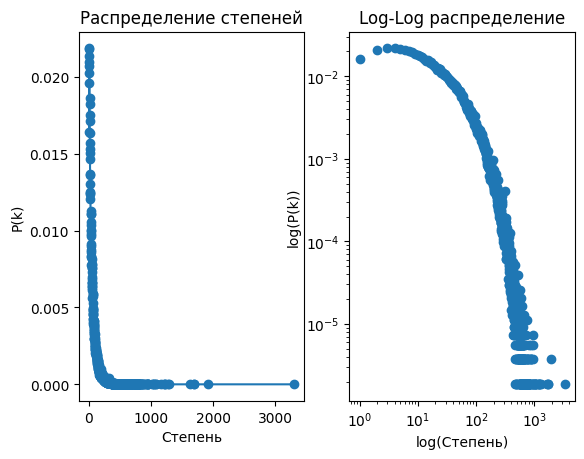


[6/23] Файл: com-youtube.ungraph.txt
Мин. степень: 1
Макс. степень: 28754
Средняя степень: 5.265045951590022


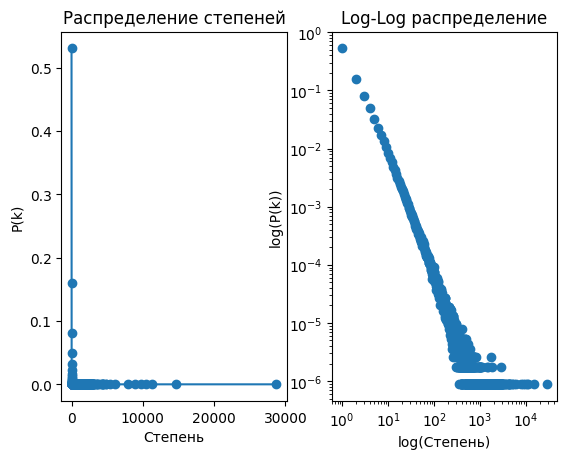


[7/23] Файл: digraph_1.txt
Мин. степень: 3
Макс. степень: 21
Средняя степень: 10.098


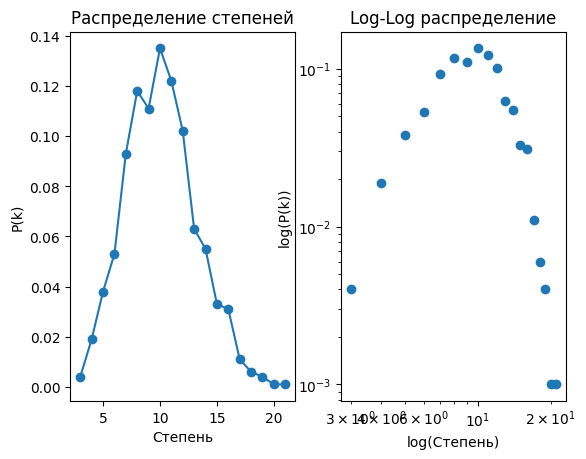


[8/23] Файл: digraph_2.txt
Мин. степень: 1
Макс. степень: 17
Средняя степень: 8.078


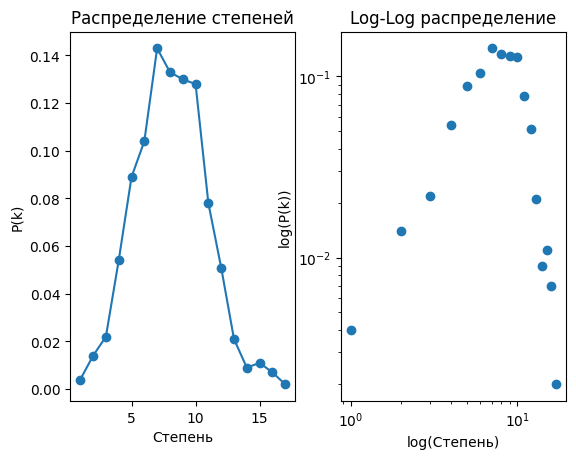


[9/23] Файл: digraph_3.txt
Мин. степень: 1
Макс. степень: 16
Средняя степень: 5.888


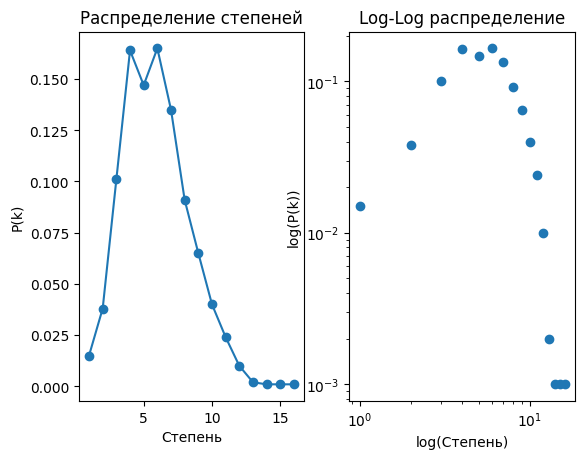


[10/23] Файл: graph_0.txt
Мин. степень: 1
Макс. степень: 17
Средняя степень: 4.588235294117647


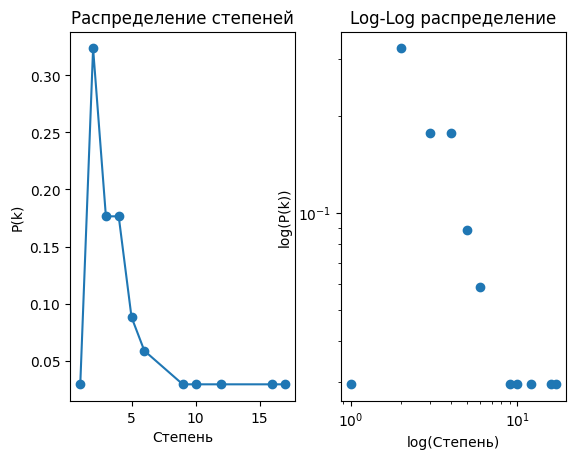


[11/23] Файл: graph_1.txt
Мин. степень: 1
Макс. степень: 313
Средняя степень: 39.11018711018711


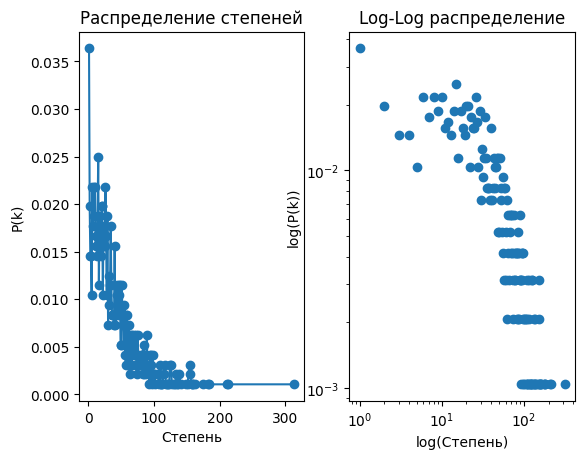


[12/23] Файл: graph_2.txt
Мин. степень: 1
Макс. степень: 473
Средняя степень: 81.04715447154472


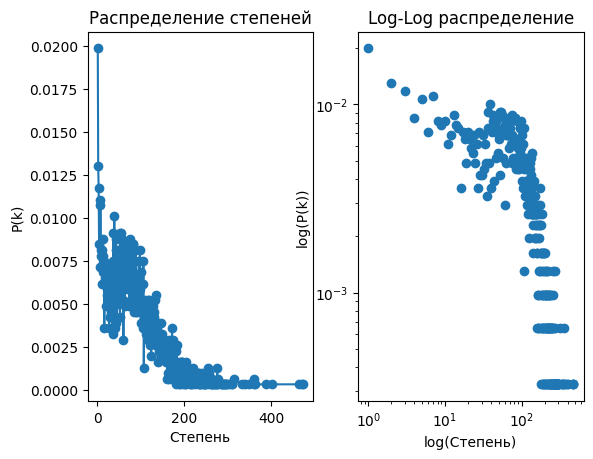


[13/23] Файл: graph_3.txt
Мин. степень: 1
Макс. степень: 8
Средняя степень: 2.303240740740741


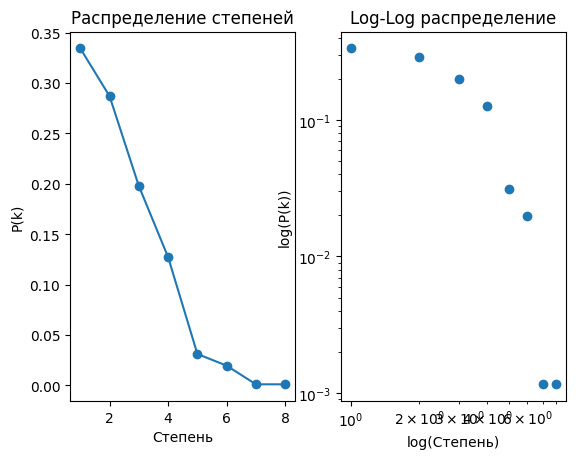


[14/23] Файл: graph_4.txt
Мин. степень: 1
Макс. степень: 10
Средняя степень: 3.0303664921465967


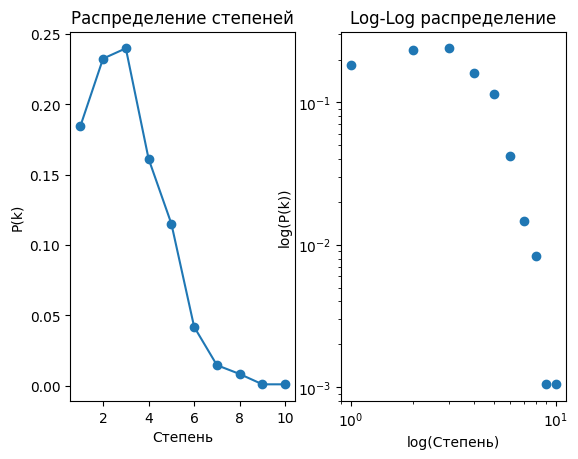


[15/23] Файл: graph_5.txt
Мин. степень: 1
Макс. степень: 14
Средняя степень: 5.025227043390514


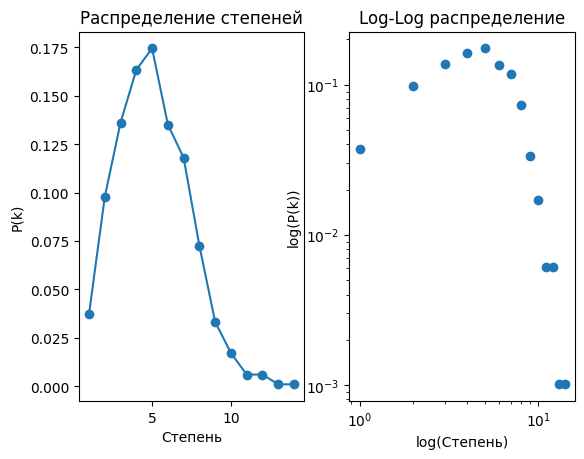


[16/23] Файл: graph_6.txt
Мин. степень: 1
Макс. степень: 19
Средняя степень: 7.481481481481482


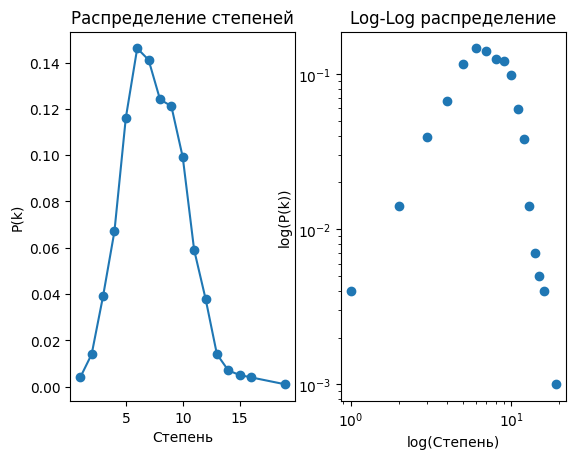


[17/23] Файл: graph_7.txt
Мин. степень: 1
Макс. степень: 23
Средняя степень: 10.076


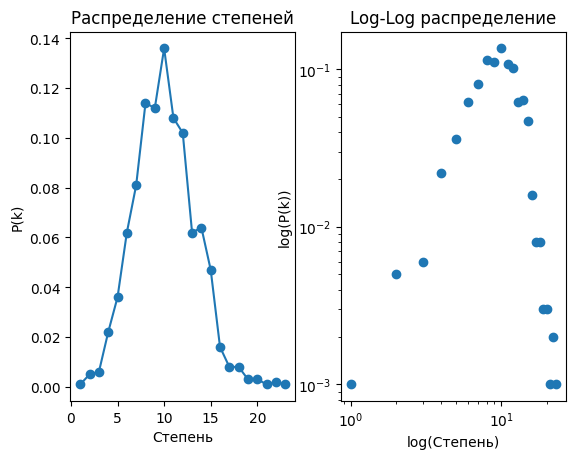


[18/23] Файл: graph_8.txt
Мин. степень: 70
Макс. степень: 133
Средняя степень: 99.704


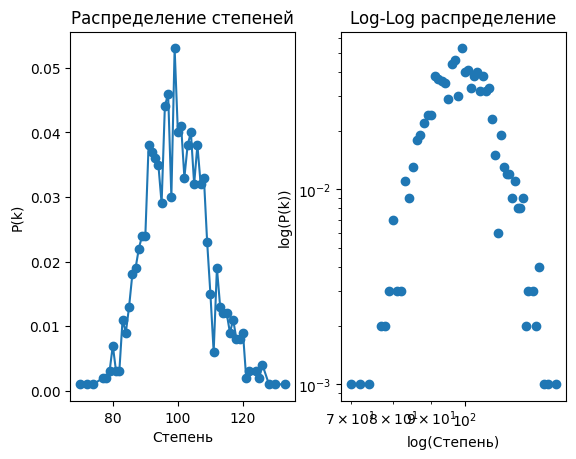


[19/23] Файл: musae_git_edges.txt
Мин. степень: 1
Макс. степень: 9458
Средняя степень: 15.331724137931035


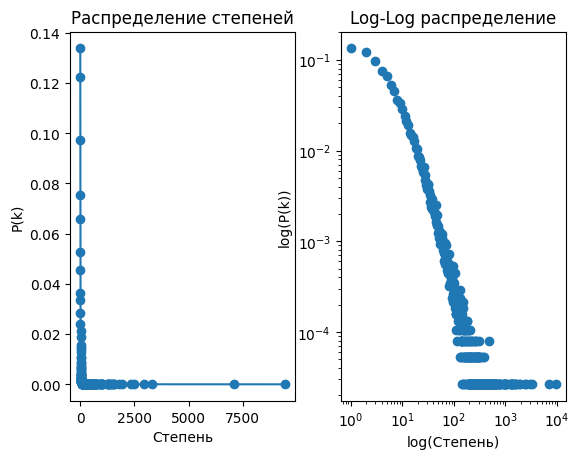


[20/23] Файл: soc-wiki-Vote.txt
Мин. степень: 1
Макс. степень: 102
Средняя степень: 6.555680539932508


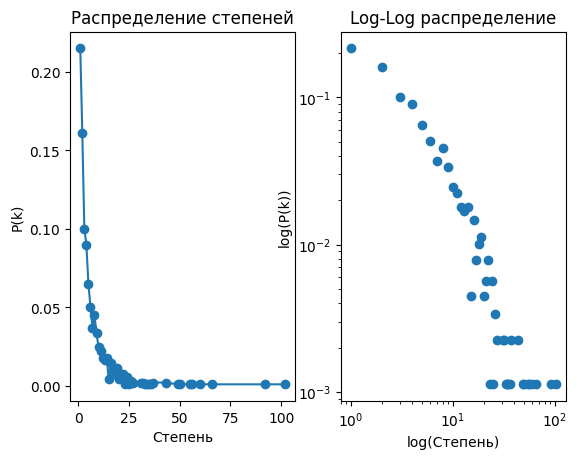


[21/23] Файл: web-Google.txt
Мин. степень: 1
Макс. степень: 6332
Средняя степень: 9.870930316210904


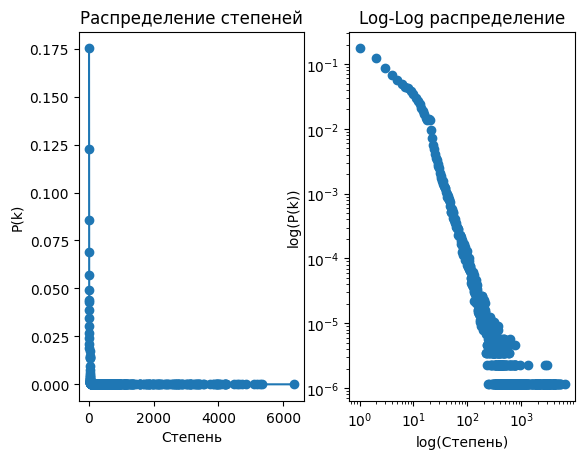


[22/23] Файл: web-NotreDame.txt
Мин. степень: 1
Макс. степень: 10721
Средняя степень: 6.693343239318574


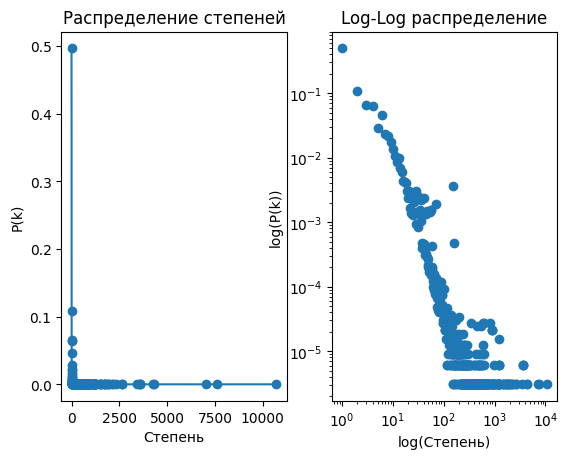


[23/23] Файл: web-Stanford.txt
Мин. степень: 1
Макс. степень: 38625
Средняя степень: 14.13703295105054


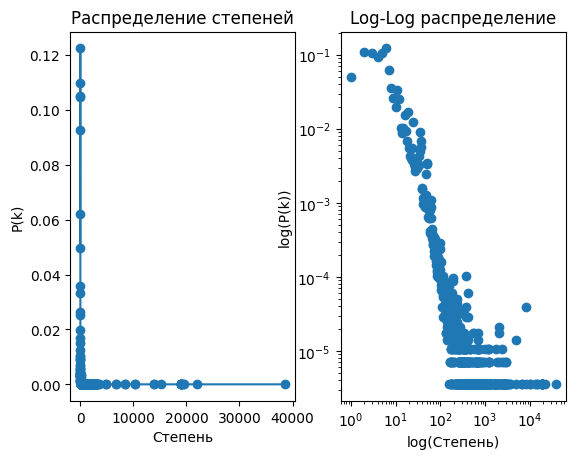

In [5]:
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import os
import glob

def read_graph(path):
    graph = defaultdict(set)
    with open(path, 'r') as f:
        for line in f:
            u, v = map(int, line.strip().split())
            if u == v:
                continue
            graph[u].add(v)
            graph[v].add(u)
    return graph

def degree_stats(graph):
    degrees = [len(neighbors) for neighbors in graph.values()]
    min_deg = min(degrees)
    max_deg = max(degrees)
    avg_deg = sum(degrees) / len(degrees)
    return degrees, min_deg, max_deg, avg_deg

def degree_distribution(degrees):
    counter = Counter(degrees)
    total = sum(counter.values())
    pdf = {deg: count / total for deg, count in counter.items()}
    return pdf

def plot_degree_distribution(pdf):
    x = sorted(pdf.keys())
    y = [pdf[d] for d in x]
    plt.subplot(1, 2, 1)
    plt.plot(x, y, marker='o')
    plt.title("Распределение степеней")
    plt.xlabel("Степень")
    plt.ylabel("P(k)")
    plt.subplot(1, 2, 2)
    plt.loglog(x, y, marker='o', linestyle='None')
    plt.title("Log-Log распределение")
    plt.xlabel("log(Степень)")
    plt.ylabel("log(P(k))")
    plt.show()

txt_files = sorted(glob.glob(os.path.join("*.txt")))
for i, file in enumerate(txt_files, 1):
    print(f"\n[{i}/{len(txt_files)}] Файл: {os.path.basename(file)}")
    graph = read_graph(os.path.basename(file))
    degrees, dmin, dmax, davg = degree_stats(graph)
    print(f"Мин. степень: {dmin}")
    print(f"Макс. степень: {dmax}")
    print(f"Средняя степень: {davg}")
    pdf = degree_distribution(degrees)
    plot_degree_distribution(pdf)


[1/23] Файл: CA-AstroPh.txt
0%: случайное = 0.9537584571946087, по степени = 0.9537584571946087
5%: случайное = 0.9471765827398643, по степени = 0.9378679975326641
10%: случайное = 0.9396827275955961, по степени = 0.9068900201254884
15%: случайное = 0.9295562797693657, по степени = 0.8737152168463274
20%: случайное = 0.9237530798428448, по степени = 0.8200039954717986
25%: случайное = 0.911570424035798, по степени = 0.7412458271184033
30%: случайное = 0.9039573820395739, по степени = 0.6267123287671232
35%: случайное = 0.8888706769382069, по степени = 0.4651696443206032
40%: случайное = 0.8748113291307822, по степени = 0.22862470034626653
45%: случайное = 0.8642130750605327, по степени = 0.0475544794188862
50%: случайное = 0.8375239718730023, по степени = 0.007564457702961858


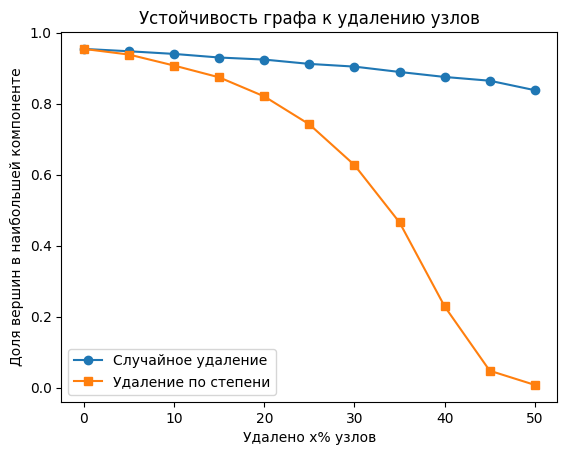


[2/23] Файл: CA-GrQc.txt
0%: случайное = 0.7933600457927876, по степени = 0.7933600457927876
5%: случайное = 0.7630046194014862, по степени = 0.710383611166901
10%: случайное = 0.741997032011872, по степени = 0.5420818316726733
15%: случайное = 0.7310886644219977, по степени = 0.05499438832772166
20%: случайное = 0.7119007870259957, по степени = 0.009301216312902457
25%: случайное = 0.6761638259984737, по степени = 0.005087763927753753
30%: случайное = 0.646225129463069, по степени = 0.002998092123194331
35%: случайное = 0.6604050484297036, по степени = 0.0029351335485764602
40%: случайное = 0.5602543720190779, по степени = 0.0022257551669316376
45%: случайное = 0.5515088449531738, по степени = 0.002081165452653486
50%: случайное = 0.48416634872186187, по степени = 0.002289202594429607


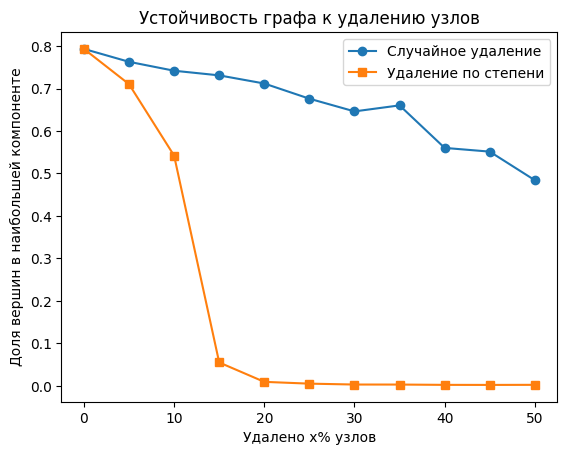


[3/23] Файл: Email-EuAll.txt
0%: случайное = 0.8483938281341389, по степени = 0.8483938281341389
5%: случайное = 0.8187036014601266, по степени = 3.574847373877399e-05
10%: случайное = 0.7627636692954983, по степени = 2.096356950890742e-05
15%: случайное = 0.7441600298324588, по степени = 8.878707970416145e-06
20%: случайное = 0.7026197124636806, по степени = 9.43360627900834e-06
25%: случайное = 0.6328330574520645, по степени = 1.0062538677883044e-05
30%: случайное = 0.6357064692976545, по степени = 1.0781264318866674e-05
35%: случайное = 0.5499721344974922, по степени = 1.1610626044956345e-05
40%: случайное = 0.5549161666855339, по степени = 1.2578141705344452e-05
45%: случайное = 0.5111522760797228, по степени = 1.3721656203903811e-05
50%: случайное = 0.43107807252556507, по степени = 1.5093770046413342e-05


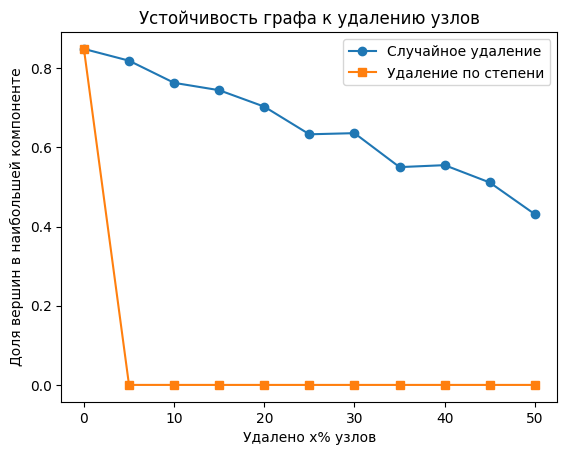


[4/23] Файл: Wiki-Vote.txt
0%: случайное = 0.9931131412508785, по степени = 0.9931131412508785
5%: случайное = 0.975887573964497, по степени = 0.8640532544378698
10%: случайное = 0.957682698313554, по степени = 0.7406308557151781
15%: случайное = 0.9408068783068783, по степени = 0.6096230158730159
20%: случайное = 0.9234012649332396, по степени = 0.4425509486999297
25%: случайное = 0.9055649241146712, по степени = 0.23833614390106803
30%: случайное = 0.8998193133908854, по степени = 0.01465569162818711
35%: случайное = 0.8732972972972973, по степени = 0.005189189189189189
40%: случайное = 0.8379011478097915, по степени = 0.0011712344811431249
45%: случайное = 0.8193663771078181, по степени = 0.0012774655084312723
50%: случайное = 0.8046655424395728, по степени = 0.0008431703204047217


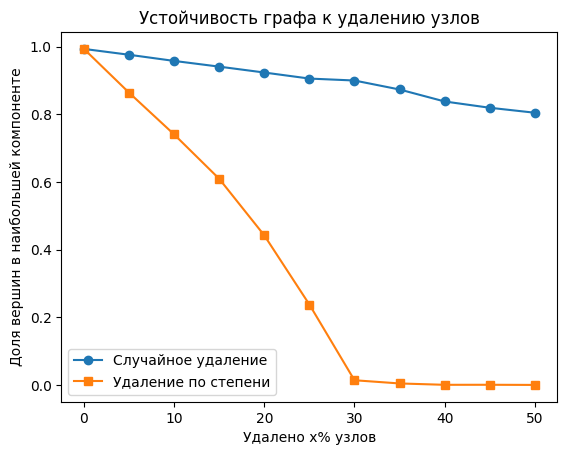


[5/23] Файл: ca-coauthors-dblp.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 0.9958458464306998, по степени = 0.9979024737955292
10%: случайное = 0.990625732364659, по степени = 0.994568680900752
15%: случайное = 0.9864610133779118, по степени = 0.9892754683139826
20%: случайное = 0.9803001463959536, по степени = 0.9807534419238232
25%: случайное = 0.9745143265945506, по степени = 0.9692252661181898
30%: случайное = 0.9671407539759106, по степени = 0.9508697180585768
35%: случайное = 0.9593158296234728, по степени = 0.9239374238577235
40%: случайное = 0.9506247455996447, по степени = 0.8861427355593108
45%: случайное = 0.9398657104027343, по степени = 0.8312364600293338
50%: случайное = 0.9300666437243518, по степени = 0.7494440189015071


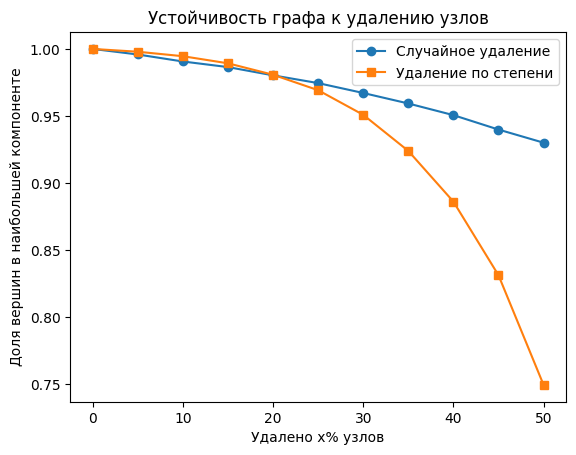


[6/23] Файл: com-youtube.ungraph.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 0.9604348576166865, по степени = 0.3124215087752494
10%: случайное = 0.9199090269149922, по степени = 0.0010603083411901888
15%: случайное = 0.8886049652881801, по степени = 6.84181009415782e-05
20%: случайное = 0.8526156720034541, по степени = 2.753570830653191e-05
25%: случайное = 0.8087146133313282, по степени = 1.644798676641979e-05
30%: случайное = 0.758811111964281, по степени = 1.2587752368700301e-05
35%: случайное = 0.7177864626754997, по степени = 8.133619094484186e-06
40%: случайное = 0.675265150513853, по степени = 8.811426658090212e-06
45%: случайное = 0.6415802880533171, по степени = 9.612457745237828e-06
50%: случайное = 0.5952418296046312, по степени = 1.7622853316180423e-06


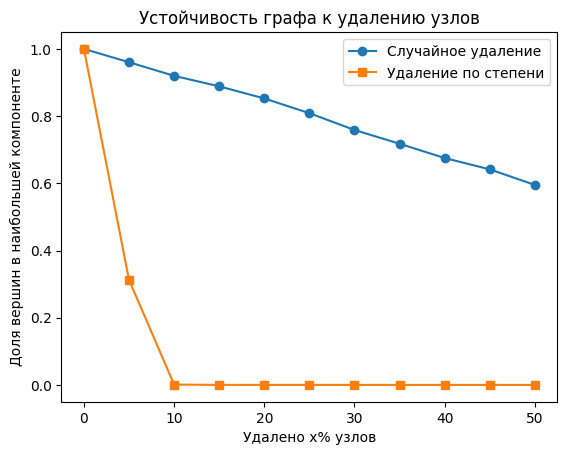


[7/23] Файл: digraph_1.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 1.0, по степени = 1.0
10%: случайное = 1.0, по степени = 1.0
15%: случайное = 1.0, по степени = 1.0
20%: случайное = 1.0, по степени = 1.0
25%: случайное = 1.0, по степени = 1.0
30%: случайное = 1.0, по степени = 0.9985714285714286
35%: случайное = 0.9984615384615385, по степени = 0.9969230769230769
40%: случайное = 0.9983333333333333, по степени = 0.9966666666666667
45%: случайное = 1.0, по степени = 0.9836363636363636
50%: случайное = 0.996, по степени = 0.956


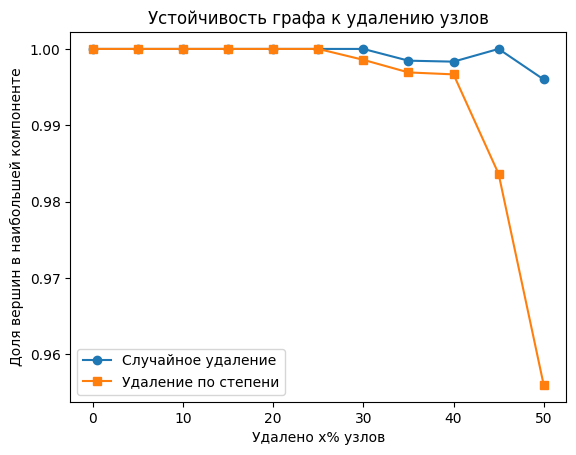


[8/23] Файл: digraph_2.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 1.0, по степени = 0.9968421052631579
10%: случайное = 1.0, по степени = 0.9966666666666667
15%: случайное = 0.9988235294117647, по степени = 0.9952941176470588
20%: случайное = 1.0, по степени = 0.99125
25%: случайное = 0.9973333333333333, по степени = 0.9853333333333333
30%: случайное = 0.9971428571428571, по степени = 0.9785714285714285
35%: случайное = 0.9953846153846154, по степени = 0.9723076923076923
40%: случайное = 0.9966666666666667, по степени = 0.9566666666666667
45%: случайное = 0.9836363636363636, по степени = 0.9163636363636364
50%: случайное = 0.986, по степени = 0.84


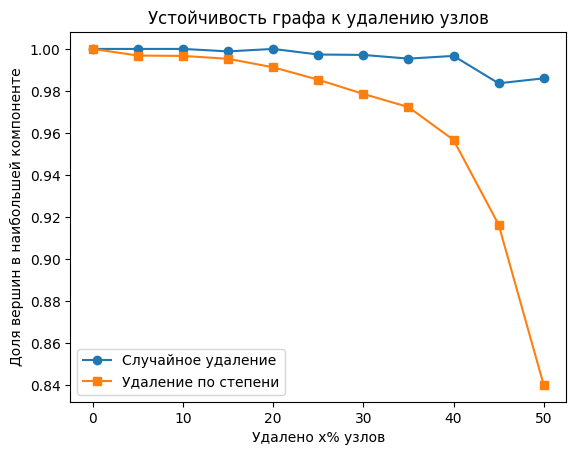


[9/23] Файл: digraph_3.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 1.0, по степени = 0.9978947368421053
10%: случайное = 0.9966666666666667, по степени = 0.9955555555555555
15%: случайное = 0.9964705882352941, по степени = 0.9847058823529412
20%: случайное = 0.99375, по степени = 0.97625
25%: случайное = 0.988, по степени = 0.968
30%: случайное = 0.9885714285714285, по степени = 0.94
35%: случайное = 0.9846153846153847, по степени = 0.88
40%: случайное = 0.975, по степени = 0.79
45%: случайное = 0.9563636363636364, по степени = 0.6381818181818182
50%: случайное = 0.954, по степени = 0.402


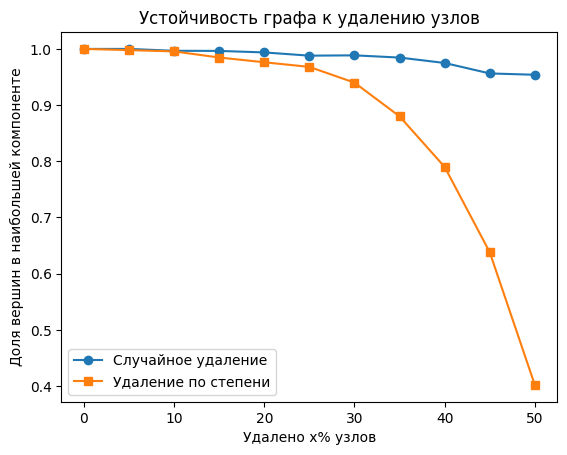


[10/23] Файл: graph_0.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 1.0, по степени = 1.0
10%: случайное = 1.0, по степени = 0.6451612903225806
15%: случайное = 1.0, по степени = 0.27586206896551724
20%: случайное = 1.0, по степени = 0.2857142857142857
25%: случайное = 0.9615384615384616, по степени = 0.23076923076923078
30%: случайное = 1.0, по степени = 0.20833333333333334
35%: случайное = 1.0, по степени = 0.17391304347826086
40%: случайное = 0.8571428571428571, по степени = 0.14285714285714285
45%: случайное = 0.8421052631578947, по степени = 0.10526315789473684
50%: случайное = 0.7058823529411765, по степени = 0.11764705882352941


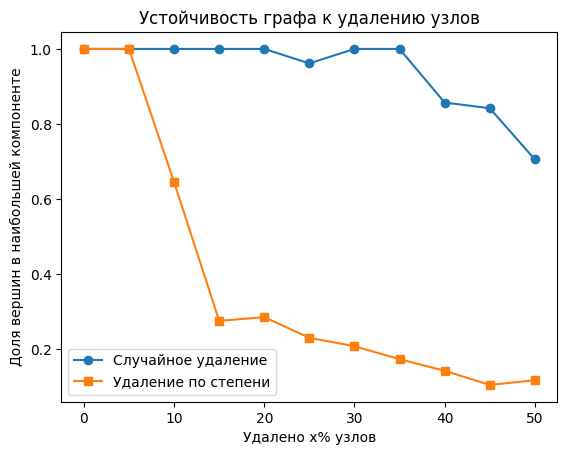


[11/23] Файл: graph_1.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 0.9989059080962801, по степени = 0.9934354485776805
10%: случайное = 0.9976905311778291, по степени = 0.9896073903002309
15%: случайное = 0.9877750611246944, по степени = 0.9841075794621027
20%: случайное = 0.9935064935064936, по степени = 0.9805194805194806
25%: случайное = 0.9861495844875346, по степени = 0.9667590027700831
30%: случайное = 0.9807121661721068, по степени = 0.9465875370919882
35%: случайное = 0.9904153354632588, по степени = 0.9345047923322684
40%: случайное = 0.9792387543252595, по степени = 0.9117647058823529
45%: случайное = 0.960377358490566, по степени = 0.8528301886792453
50%: случайное = 0.9646569646569647, по степени = 0.7983367983367984


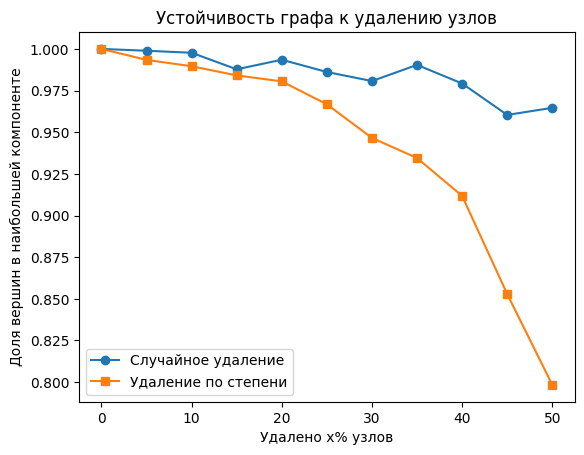


[12/23] Файл: graph_2.txt
0%: случайное = 0.9980487804878049, по степени = 0.9980487804878049
5%: случайное = 0.9965776865160849, по степени = 0.9948665297741273
10%: случайное = 0.9963872832369942, по степени = 0.9927745664739884
15%: случайное = 0.995026778882938, по степени = 0.9881407804131599
20%: случайное = 0.9955284552845528, по степени = 0.9861788617886179
25%: случайное = 0.9934980494148244, по степени = 0.9813610749891634
30%: случайное = 0.9911751045053414, по степени = 0.9753831862517418
35%: случайное = 0.9904952476238119, по степени = 0.9699849924962481
40%: случайное = 0.9902439024390244, по степени = 0.962059620596206
45%: случайное = 0.9858156028368794, по степени = 0.9521276595744681
50%: случайное = 0.9843953185955787, по степени = 0.9434330299089727


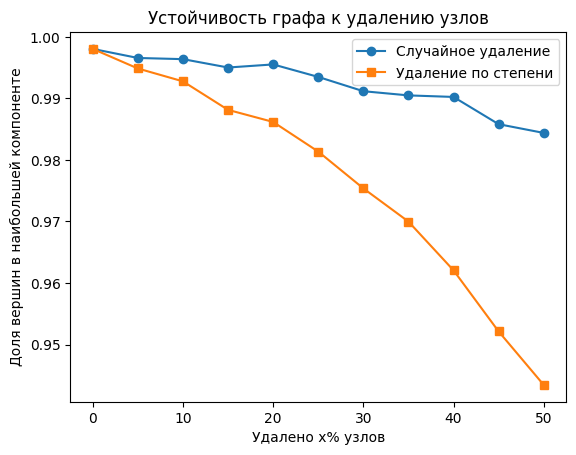


[13/23] Файл: graph_3.txt
0%: случайное = 0.90625, по степени = 0.90625
5%: случайное = 0.8781973203410475, по степени = 0.7210718635809987
10%: случайное = 0.8496143958868895, по степени = 0.48586118251928023
15%: случайное = 0.8204081632653061, по степени = 0.0380952380952381
20%: случайное = 0.7095375722543352, по степени = 0.023121387283236993
25%: случайное = 0.6435185185185185, по степени = 0.021604938271604937
30%: случайное = 0.6628099173553719, по степени = 0.01652892561983471
35%: случайное = 0.5249110320284698, по степени = 0.010676156583629894
40%: случайное = 0.2581888246628131, по степени = 0.011560693641618497
45%: случайное = 0.21218487394957983, по степени = 0.012605042016806723
50%: случайное = 0.1388888888888889, по степени = 0.009259259259259259


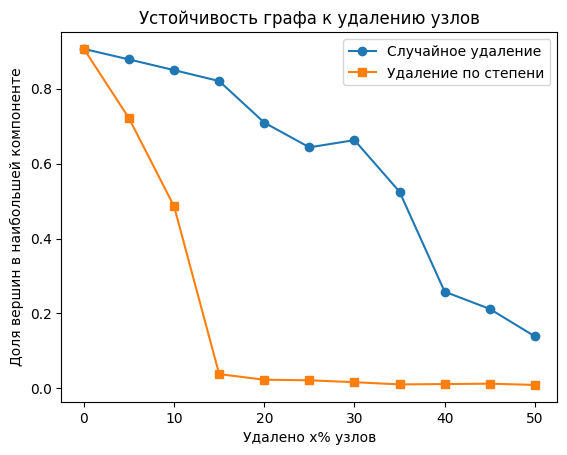


[14/23] Файл: graph_4.txt
0%: случайное = 0.9916230366492147, по степени = 0.9916230366492147
5%: случайное = 0.9779735682819384, по степени = 0.9493392070484582
10%: случайное = 0.9604651162790697, по степени = 0.8872093023255814
15%: случайное = 0.9532019704433498, по степени = 0.7598522167487685
20%: случайное = 0.9332460732984293, по степени = 0.5680628272251309
25%: случайное = 0.902370990237099, по степени = 0.3110181311018131
30%: случайное = 0.8579970104633782, по степени = 0.03886397608370702
35%: случайное = 0.7793880837359098, по степени = 0.030595813204508857
40%: случайное = 0.7486910994764397, по степени = 0.019197207678883072
45%: случайное = 0.7053231939163498, по степени = 0.02091254752851711
50%: случайное = 0.602510460251046, по степени = 0.02301255230125523


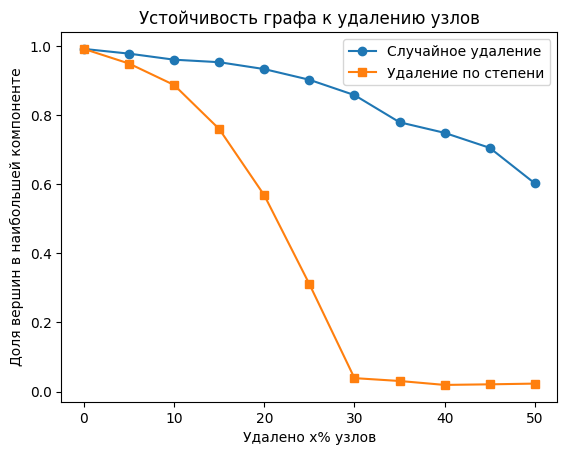


[15/23] Файл: graph_5.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 0.9978768577494692, по степени = 0.9968152866242038
10%: случайное = 0.9910313901345291, по степени = 0.984304932735426
15%: случайное = 0.9893238434163701, по степени = 0.9715302491103203
20%: случайное = 0.9886506935687264, по степени = 0.9445145018915511
25%: случайное = 0.9704301075268817, по степени = 0.9032258064516129
30%: случайное = 0.9668587896253602, по степени = 0.8414985590778098
35%: случайное = 0.958139534883721, по степени = 0.7116279069767442
40%: случайное = 0.957983193277311, по степени = 0.44873949579831934
45%: случайное = 0.9395604395604396, по степени = 0.184981684981685
50%: случайное = 0.8770161290322581, по степени = 0.056451612903225805


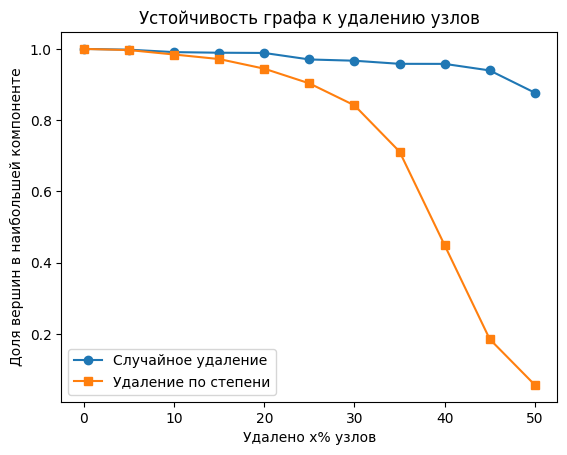


[16/23] Файл: graph_6.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 1.0, по степени = 1.0
10%: случайное = 1.0, по степени = 0.9977777777777778
15%: случайное = 0.9988235294117647, по степени = 0.9964705882352941
20%: случайное = 0.99375, по степени = 0.99375
25%: случайное = 0.9973333333333333, по степени = 0.9853333333333333
30%: случайное = 0.9942857142857143, по степени = 0.9785714285714285
35%: случайное = 0.9953846153846154, по степени = 0.9646153846153847
40%: случайное = 0.985, по степени = 0.9416666666666667
45%: случайное = 0.9890909090909091, по степени = 0.8672727272727273
50%: случайное = 0.968, по степени = 0.728


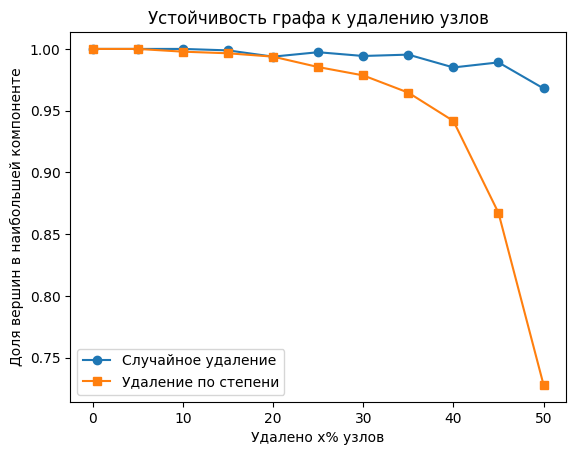


[17/23] Файл: graph_7.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 1.0, по степени = 0.9989473684210526
10%: случайное = 1.0, по степени = 0.9988888888888889
15%: случайное = 1.0, по степени = 0.9988235294117647
20%: случайное = 0.99875, по степени = 0.99875
25%: случайное = 1.0, по степени = 0.9973333333333333
30%: случайное = 1.0, по степени = 0.9971428571428571
35%: случайное = 0.9984615384615385, по степени = 0.9938461538461538
40%: случайное = 0.9966666666666667, по степени = 0.985
45%: случайное = 0.9981818181818182, по степени = 0.9709090909090909
50%: случайное = 0.994, по степени = 0.952


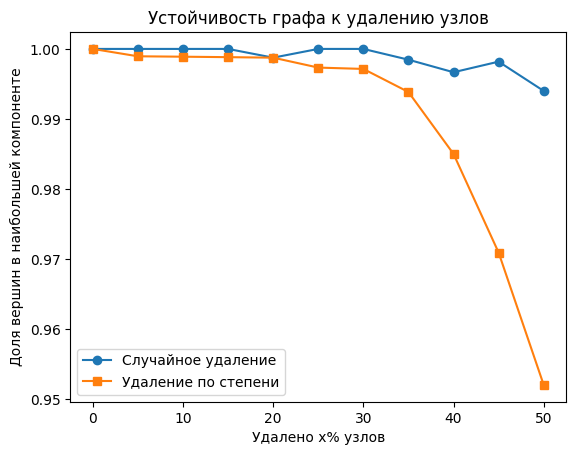


[18/23] Файл: graph_8.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 1.0, по степени = 1.0
10%: случайное = 1.0, по степени = 1.0
15%: случайное = 1.0, по степени = 1.0
20%: случайное = 1.0, по степени = 1.0
25%: случайное = 1.0, по степени = 1.0
30%: случайное = 1.0, по степени = 1.0
35%: случайное = 1.0, по степени = 1.0
40%: случайное = 1.0, по степени = 1.0
45%: случайное = 1.0, по степени = 1.0
50%: случайное = 1.0, по степени = 1.0


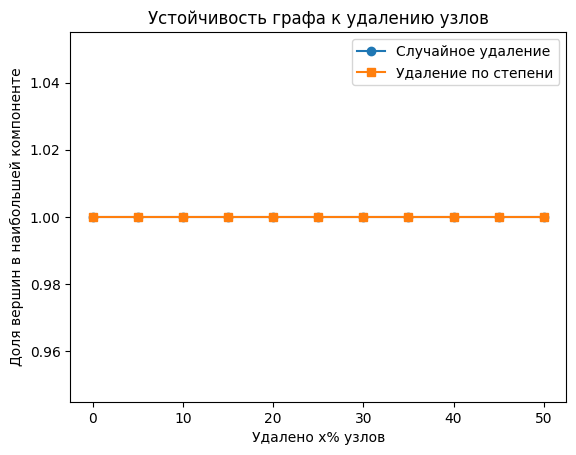


[19/23] Файл: musae_git_edges.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 0.992377495462795, по степени = 0.8229512773977383
10%: случайное = 0.9853521956970233, по степени = 0.7329501915708813
15%: случайное = 0.9612420034326729, по степени = 0.6287720393197067
20%: случайное = 0.9577586206896552, по степени = 0.48332228116710874
25%: случайное = 0.9539876215738284, по степени = 0.2848452696728559
30%: случайное = 0.9491852974611595, по степени = 0.05327775672603259
35%: случайное = 0.9334421546623138, по степени = 0.003795143848194246
40%: случайное = 0.904686118479222, по степени = 0.0010167992926613616
45%: случайное = 0.8938509766095973, по степени = 0.0009163250542560887
50%: случайное = 0.8771883289124669, по степени = 0.000689655172413793


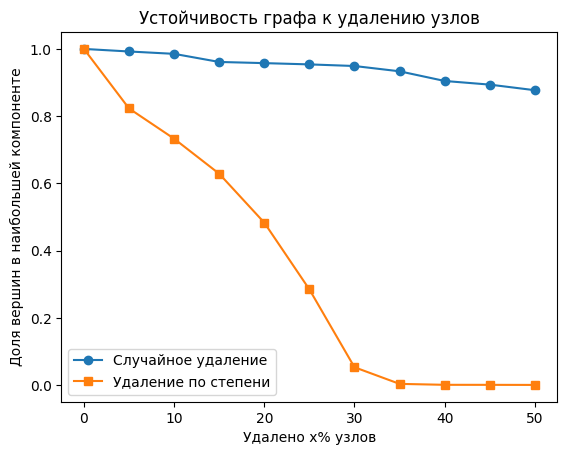


[20/23] Файл: soc-wiki-Vote.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 0.9928994082840237, по степени = 0.9289940828402367
10%: случайное = 0.9712858926342073, по степени = 0.8177278401997503
15%: случайное = 0.9576719576719577, по степени = 0.7142857142857143
20%: случайное = 0.9367977528089888, по степени = 0.5884831460674157
25%: случайное = 0.9295352323838081, по степени = 0.2698650674662669
30%: случайное = 0.9197431781701445, по степени = 0.07865168539325842
35%: случайное = 0.8823529411764706, по степени = 0.029411764705882353
40%: случайное = 0.8857677902621723, по степени = 0.02247191011235955
45%: случайное = 0.8282208588957055, по степени = 0.012269938650306749
50%: случайное = 0.8044943820224719, по степени = 0.01348314606741573


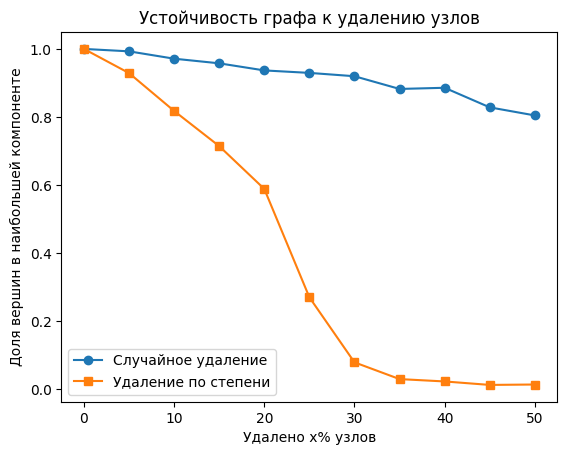


[21/23] Файл: web-Google.txt
0%: случайное = 0.9772630987549574, по степени = 0.9772630987549574
5%: случайное = 0.9606456327951457, по степени = 0.7512188554778779
10%: случайное = 0.9403356247985769, по степени = 0.5643919496740435
15%: случайное = 0.9224055124086964, по степени = 0.3962131074202298
20%: случайное = 0.9000072797760684, по степени = 0.2378645419236594
25%: случайное = 0.8745982322982406, по степени = 0.0916768805621322
30%: случайное = 0.8515252854812398, по степени = 0.006391517128874388
35%: случайное = 0.8215152824772406, по степени = 0.0005498810640637791
40%: случайное = 0.7988516028837443, по степени = 0.0002645462365918832
45%: случайное = 0.7652472889671396, по степени = 0.00012042114180004693
50%: случайное = 0.7197783751316069, по степени = 7.536707189790274e-05


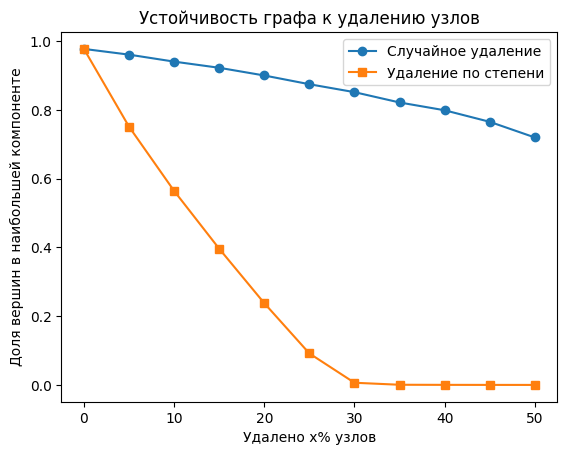


[22/23] Файл: web-NotreDame.txt
0%: случайное = 1.0, по степени = 1.0
5%: случайное = 0.9555039215622909, по степени = 0.29928290509075983
10%: случайное = 0.9069781721057317, по степени = 0.05127627858110159
15%: случайное = 0.8679994221114603, по степени = 0.0026944053165745656
20%: случайное = 0.8040938814355447, по степени = 0.002133668989654008
25%: случайное = 0.7430586540153993, по степени = 0.002226797709345592
30%: случайное = 0.7048081013635307, по степени = 0.00037278903210810003
35%: случайное = 0.6530577544350191, по степени = 0.00015586329372201544
40%: случайное = 0.5826297854050901, по степени = 0.00014838465395675354
45%: случайное = 0.5781826503898946, по степени = 0.0001618746197341907
50%: случайное = 0.5063273263132042, по степени = 0.00016578147545513155


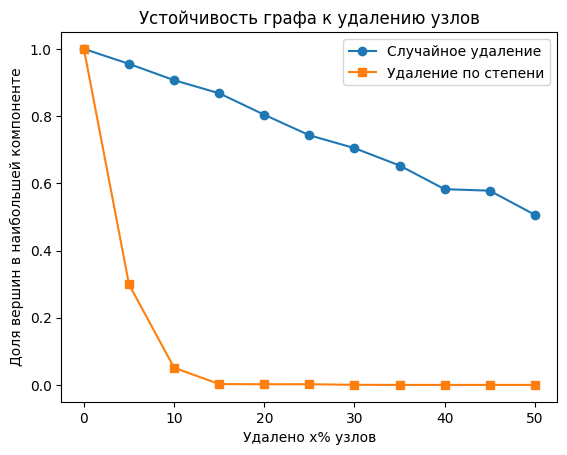


[23/23] Файл: web-Stanford.txt
0%: случайное = 0.9055065040102447, по степени = 0.9055065040102447
5%: случайное = 0.8842342275062731, по степени = 0.4879577906559924
10%: случайное = 0.848056662449303, по степени = 0.3627563427967822
15%: случайное = 0.8293116543832266, по степени = 0.2613910474171389
20%: случайное = 0.805514293442354, по степени = 0.09763527445094292
25%: случайное = 0.7773946686342396, по степени = 0.10241784437255236
30%: случайное = 0.7603087167376972, по степени = 0.04191392215189553
35%: случайное = 0.6952853408427337, по степени = 0.032542554178468325
40%: случайное = 0.6893024795733762, по степени = 0.024387792505705264
45%: случайное = 0.6883461144040194, по степени = 0.00621101988429315
50%: случайное = 0.6337618480049946, по степени = 0.005356433395765935


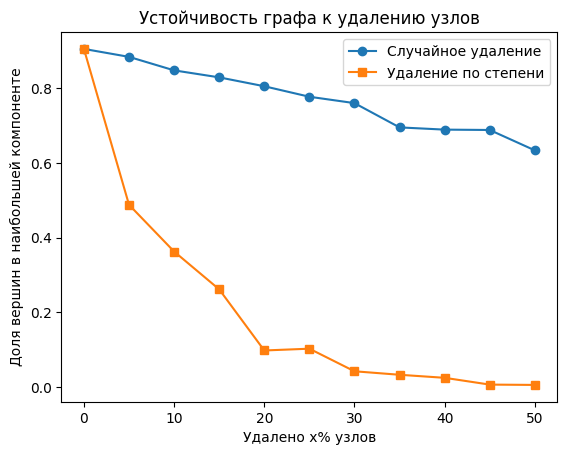

In [6]:
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import os
import glob

def read_graph(path):
    graph = defaultdict(set)
    with open(path, 'r') as f:
        for line in f:
            u, v = map(int, line.strip().split())
            if u == v:
                continue
            graph[u].add(v)
            graph[v].add(u)
    return graph

def get_connected_components(graph):
    visited = set()
    components = []
    for node in graph:
        if node not in visited:
            comp = []
            queue = deque([node])
            visited.add(node)
            while queue:
                current = queue.popleft()
                comp.append(current)
                for neighbor in graph[current]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)
            components.append(comp)
    return components

def remove_nodes(graph, nodes_to_remove):
    new_graph = defaultdict(set)
    for u in graph:
        if u in nodes_to_remove:
            continue
        new_graph[u] = {v for v in graph[u] if v not in nodes_to_remove}
    return new_graph

def fragmentation_analysis(graph, percents):
    N = len(graph)
    original_nodes = set(graph.keys())
    degrees = {node: len(graph[node]) for node in graph}
    sorted_by_degree = sorted(degrees, key=degrees.get, reverse=True)
    random_results = []
    targeted_results = []
    for p in percents:
        num_remove = int(N * p / 100)
        to_remove_rand = set(random.sample(list(original_nodes), num_remove))
        g_rand = remove_nodes(graph, to_remove_rand)
        comps_rand = get_connected_components(g_rand)
        max_size_rand = max((len(c) for c in comps_rand), default=0)
        random_results.append(max_size_rand / (N - num_remove))
        to_remove_deg = set(sorted_by_degree[:num_remove])
        g_deg = remove_nodes(graph, to_remove_deg)
        comps_deg = get_connected_components(g_deg)
        max_size_deg = max((len(c) for c in comps_deg), default=0)
        targeted_results.append(max_size_deg / (N - num_remove))
    return random_results, targeted_results

def plot_fragmentation(percents, rand_results, deg_results):
    plt.plot(percents, rand_results, marker='o', label='Случайное удаление')
    plt.plot(percents, deg_results, marker='s', label='Удаление по степени')
    plt.xlabel("Удалено x% узлов")
    plt.ylabel("Доля вершин в наибольшей компоненте")
    plt.title("Устойчивость графа к удалению узлов")
    plt.legend()
    plt.show()

txt_files = sorted(glob.glob(os.path.join("*.txt")))
for i, file in enumerate(txt_files, 1):
    print(f"\n[{i}/{len(txt_files)}] Файл: {os.path.basename(file)}")
    graph = read_graph(os.path.basename(file))
    percents = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
    rand_res, deg_res = fragmentation_analysis(graph, percents)
    for p, r, d in zip(percents, rand_res, deg_res):
        print(f"{p}%: случайное = {r}, по степени = {d}")
    plot_fragmentation(percents, rand_res, deg_res)

In [2]:
import random
import time
from collections import defaultdict, deque
import numpy as np
import os
import glob

def read_graph(file_path):
    graph = defaultdict(set)
    with open(file_path, 'r') as f:
        for line in f:
            u, v = map(int, line.strip().split())
            if u != v:
                graph[u].add(v)
                graph[v].add(u)
    return graph

def bfs_distances(graph, source):
    dist = {source: 0}
    queue = deque([source])
    while queue:
        node = queue.popleft()
        for neighbor in graph[node]:
            if neighbor not in dist:
                dist[neighbor] = dist[node] + 1
                queue.append(neighbor)
    return dist

def select_highest_degree(graph, k):
    degree_list = sorted(graph.items(), key=lambda item: len(item[1]), reverse=True)
    return [node for node, _ in degree_list[:k]]

def select_random(graph, k):
    return random.sample(list(graph.keys()), k)

def select_best_coverage(graph, k, M=100):
    P = []
    nodes = list(graph.keys())
    for _ in range(M):
        s, t = random.sample(nodes, 2)
        dist = bfs_distances(graph, s)
        path = []
        if t in dist:
            current = t
            while current != s:
                for neighbor in graph[current]:
                    if dist.get(neighbor, float('inf')) == dist[current] - 1:
                        path.append(current)
                        current = neighbor
                        break
            path.append(s)
            P.append(set(path))
    Vp = set.union(*P) if P else set()
    c = defaultdict(int)
    for v in Vp:
        c[v] = sum(1 for path in P if v in path)
    landmarks = []
    for _ in range(k):
        if not c:
            break
        u = max(c, key=c.get)
        landmarks.append(u)
        c.pop(u)
    return landmarks

def precompute_landmarks(graph, landmark_nodes):
    landmark_dists = {}
    for lm in landmark_nodes:
        landmark_dists[lm] = bfs_distances(graph, lm)
    return landmark_dists

def landmark_distance(s, t, landmark_dists):
    approx = float('inf')
    for lm, dist_map in landmark_dists.items():
        if s in dist_map and t in dist_map:
            approx = min(approx, dist_map[s] + dist_map[t])
    return approx if approx != float('inf') else None

def evaluate(graph, landmark_nodes, landmark_dists, num_pairs=100):
    nodes = list(graph.keys())
    errors = []
    exact_times = []
    approx_times = []
    for _ in range(num_pairs):
        s, t = random.sample(nodes, 2)
        t0 = time.perf_counter()
        d_exact_map = bfs_distances(graph, s)
        d_exact = d_exact_map.get(t, None)
        t1 = time.perf_counter()
        t2 = time.perf_counter()
        d_approx = landmark_distance(s, t, landmark_dists)
        t3 = time.perf_counter()
        if d_exact is not None and d_approx is not None:
            errors.append(abs(d_exact - d_approx))
            exact_times.append(t1 - t0)
            approx_times.append(t3 - t2)
    return {
        'avg_error': np.mean(errors),
        'max_error': np.max(errors),
        'avg_exact_time': np.mean(exact_times),
        'avg_approx_time': np.mean(approx_times)
    }

def print_results(*results):
    print("\nСравнение стратегий выбора ландмарок:\n")
    headers = ["Стратегия", "Средн. ошибка", "Макс. ошибка", "Точное (ср)", "Приближ. (ср)", "Время выбора", "Общее время"]
    row_format = "{:<16} {:<14} {:<12} {:<14} {:<14} {:<14} {:<14}"
    print(row_format.format(*headers))
    print("-" * 100)
    for res in results:
        print(row_format.format(
            res["selection"],
            f"{res['avg_error']}",
            f"{res['max_error']}",
            f"{res['avg_exact_time']}",
            f"{res['avg_approx_time']}",
            f"{res['precompute_time']} секунд",
            f"{res['total_time']} секунд"
        ))

txt_files = sorted(glob.glob(os.path.join("*.txt")))
for i, file in enumerate(txt_files, 1):
    print(f"\n[{i}/{len(txt_files)}] Файл: {os.path.basename(file)}")
    landmark_count = [10, 20, 30, 40, 50]
    graph = read_graph(os.path.basename(file))
    for k in landmark_count:
        print(f"\n Количество ландмарок: {k}")
        start_time = time.perf_counter()
        landmarks_high = select_highest_degree(graph, k)
        pre_time = time.perf_counter()
        dists_high = precompute_landmarks(graph, landmarks_high)
        eval_high = evaluate(graph, landmarks_high, dists_high, num_pairs=100)
        end_time = time.perf_counter()
        eval_high["selection"] = "highest_degree"
        eval_high["total_time"] = end_time - start_time
        eval_high["precompute_time"] = pre_time - start_time
        start_time = time.perf_counter()
        landmarks_rand = select_random(graph, k)
        pre_time = time.perf_counter()
        dists_rand = precompute_landmarks(graph, landmarks_rand)
        eval_rand = evaluate(graph, landmarks_rand, dists_rand, num_pairs=100)
        end_time = time.perf_counter()
        eval_rand["selection"] = "random"
        eval_rand["total_time"] = end_time - start_time
        eval_rand["precompute_time"] = pre_time - start_time
        start_time = time.perf_counter()
        landmarks_best = select_best_coverage(graph, k, M=100)
        pre_time = time.perf_counter()
        dists_best = precompute_landmarks(graph, landmarks_best)
        eval_best = evaluate(graph, landmarks_best, dists_best, num_pairs=100)
        end_time = time.perf_counter()
        eval_best["selection"] = "best_coverage"
        eval_best["total_time"] = end_time - start_time
        eval_best["precompute_time"] = pre_time - start_time
        print_results(eval_high, eval_rand, eval_best)


[1/4] Файл: CA-AstroPh.txt

 Количество ландмарок: 10

Сравнение стратегий выбора ландмарок:

Стратегия        Средн. ошибка  Макс. ошибка Точное (ср)    Приближ. (ср)  Время выбора   Общее время   
----------------------------------------------------------------------------------------------------
highest_degree   0.7555555555555555 2            0.08839827752231535 3.803417774987692e-05 0.2966382419999718 секунд 9.224414999000146 секунд
random           2.5851063829787235 4            0.08624112458509192 3.75326276975721e-05 0.0006419249984901398 секунд 9.075972097998601 секунд
best_coverage    0.989247311827957 2            0.1261407311074201 6.002764534333506e-05 7.831184348999159 секунд 20.72559303900016 секунд

 Количество ландмарок: 20

Сравнение стратегий выбора ландмарок:

Стратегия        Средн. ошибка  Макс. ошибка Точное (ср)    Приближ. (ср)  Время выбора   Общее время   
----------------------------------------------------------------------------------------------------
h